# Smoothen and fit polynomial to average height and thae height average of RI

In [1]:
import os
import sys
import json
import imageio
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from skimage.filters import gaussian

sys.path.append("scripts/utils/")
from Microscopes import Tomocube
from file_operations import load_stack

In [2]:
data_path = "../../../../hdd_data/silja/Monolayers/"
_3DQPI    = Tomocube()

In [9]:
dataset = "MDCK_20250210_A2-1"
config  = json.load(open(f"configs/{dataset}.json"))
h_stack = load_stack(f"{data_path}height_fields/raw/{dataset}", config, param="h")

In [ ]:
# Apply Gaussian blur
blurred_hstack = []
for im in h_stack:
    blurred_hstack.append(gaussian(im, sigma=5))

In [11]:
# Fit 2nd order polynomial to mean intensity
def polynomial(t, a, b, c):
    return a*t**2 + b*t + c

frames = np.arange(len(h_stack))
param, popt = curve_fit(polynomial, frames, np.mean(blurred_hstack, axis=(1,2)), p0=[0, 1/40, 7.9])

h_mean = np.mean(blurred_hstack, axis=(1,2))

Text(0.5, 0, 'time (frame)')

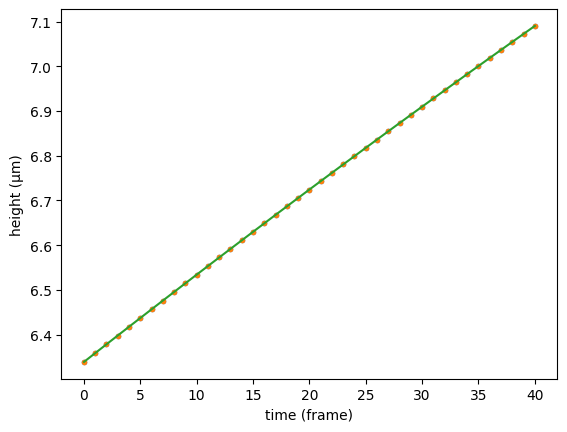

In [12]:
# rescale data to follow fit
rescaled_hstack = []

for h_im, frame in zip(blurred_hstack, frames):
    rescaled_hstack.append(h_im * _3DQPI.z_to_um * polynomial(frame, *param)/ np.mean(h_im))


plt.plot(frames, h_mean * _3DQPI.z_to_um, '.')
plt.plot(frames, np.mean(rescaled_hstack, axis=(1,2)), '.')
plt.plot(frames, polynomial(frames,  *param) * _3DQPI.z_to_um)
plt.ylabel("height (µm)")
plt.xlabel("time (frame)")

In [8]:
# save data
for i in range(len(rescaled_hstack)):
    hframe = rescaled_hstack[i] / _3DQPI.h_to_um

    imageio.imwrite(f"{data_path}height_fields/raw/{dataset}/MDCK-li_height_{i}.tiff",       np.array(hframe, dtype=np.uint16))